In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import logging




from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error



# Loading the Dataset


In [ ]:
# Load dataset
df = pd.read_csv("Traffic.csv")


In [ ]:
# high level statistics
df.describe()

,Date,CarCount,BikeCount,BusCount,TruckCount,Total
count,2976.000000,2976.000000,2976.000000,2976.000000,2976.000000,2976.000000
mean,16.000000,68.696573,14.917339,15.279570,15.324933,114.218414
std,8.945775,45.850693,12.847518,14.341986,10.603833,60.190627
min,1.000000,6.000000,0.000000,0.000000,0.000000,21.000000
25%,8.000000,19.000000,5.000000,1.000000,6.000000,55.000000
50%,16.000000,64.000000,12.000000,12.000000,14.000000,109.000000
75%,24.000000,107.000000,22.000000,25.000000,23.000000,164.000000
max,31.000000,180.000000,70.000000,50.000000,40.000000,279.000000


In [ ]:
print("Preview of Dataset:")
display(df.head(15))

Preview of Dataset:


,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation
0,12:00:00 AM,10,Tuesday,31,0,4,4,39,low
1,12:15:00 AM,10,Tuesday,49,0,3,3,55,low
2,12:30:00 AM,10,Tuesday,46,0,3,6,55,low
3,12:45:00 AM,10,Tuesday,51,0,2,5,58,low
4,1:00:00 AM,10,Tuesday,57,6,15,16,94,normal
5,1:15:00 AM,10,Tuesday,44,0,5,4,53,low
6,1:30:00 AM,10,Tuesday,37,0,1,4,42,low
7,1:45:00 AM,10,Tuesday,42,4,4,5,55,low
8,2:00:00 AM,10,Tuesday,51,0,9,7,67,low
9,2:15:00 AM,10,Tuesday,34,0,4,7,45,low


In [ ]:
print(df['Day of the week'].unique())

['Tuesday' 'Wednesday' 'Thursday' 'Friday' 'Saturday' 'Sunday' 'Monday']


# Exploratory Data Analysis

In [ ]:
df.info()

# Summary statistics
print("\nSummary Statistics:")
display(df.describe())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2976 entries, 0 to 2975
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Time               2976 non-null   object
 1   Date               2976 non-null   int64 
 2   Day of the week    2976 non-null   object
 3   CarCount           2976 non-null   int64 
 4   BikeCount          2976 non-null   int64 
 5   BusCount           2976 non-null   int64 
 6   TruckCount         2976 non-null   int64 
 7   Total              2976 non-null   int64 
 8   Traffic Situation  2976 non-null   object
dtypes: int64(6), object(3)
memory usage: 209.4+ KB

Summary Statistics:


,Date,CarCount,BikeCount,BusCount,TruckCount,Total
count,2976.000000,2976.000000,2976.000000,2976.000000,2976.000000,2976.000000
mean,16.000000,68.696573,14.917339,15.279570,15.324933,114.218414
std,8.945775,45.850693,12.847518,14.341986,10.603833,60.190627
min,1.000000,6.000000,0.000000,0.000000,0.000000,21.000000
25%,8.000000,19.000000,5.000000,1.000000,6.000000,55.000000
50%,16.000000,64.000000,12.000000,12.000000,14.000000,109.000000
75%,24.000000,107.000000,22.000000,25.000000,23.000000,164.000000
max,31.000000,180.000000,70.000000,50.000000,40.000000,279.000000



Missing Values:
Time                 0
Date                 0
Day of the week      0
CarCount             0
BikeCount            0
BusCount             0
TruckCount           0
Total                0
Traffic Situation    0
dtype: int64


In [ ]:
df['Time'] = pd.to_datetime(df['Time'], format='%I:%M:%S %p')  # e.g., "12:15:00 AM"
df['Hour'] = df['Time'].dt.hour

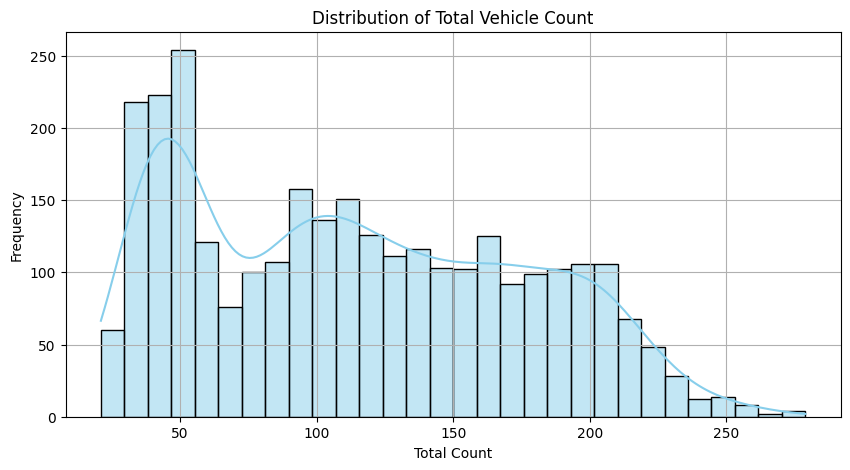

In [ ]:
# 1. Distribution of Total Vehicle Count
plt.figure(figsize=(10, 5))
sns.histplot(df['Total'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Total Vehicle Count')
plt.xlabel('Total Count')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

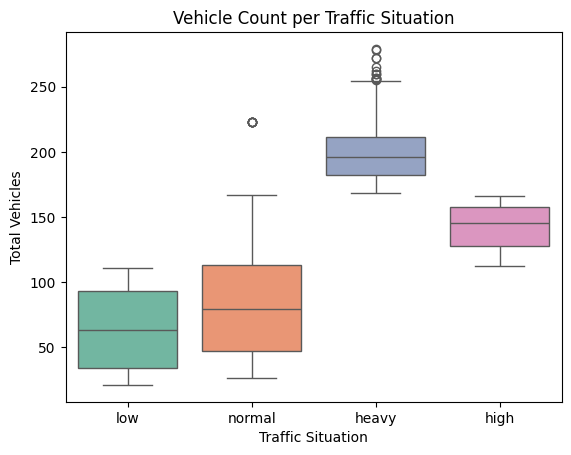

In [ ]:
# 2. Boxplot of Total by Traffic Situation
sns.boxplot(x='Traffic Situation', y='Total', data=df, hue='Traffic Situation', palette='Set2')
plt.title('Vehicle Count per Traffic Situation')
plt.xlabel('Traffic Situation')
plt.ylabel('Total Vehicles')
plt.show()


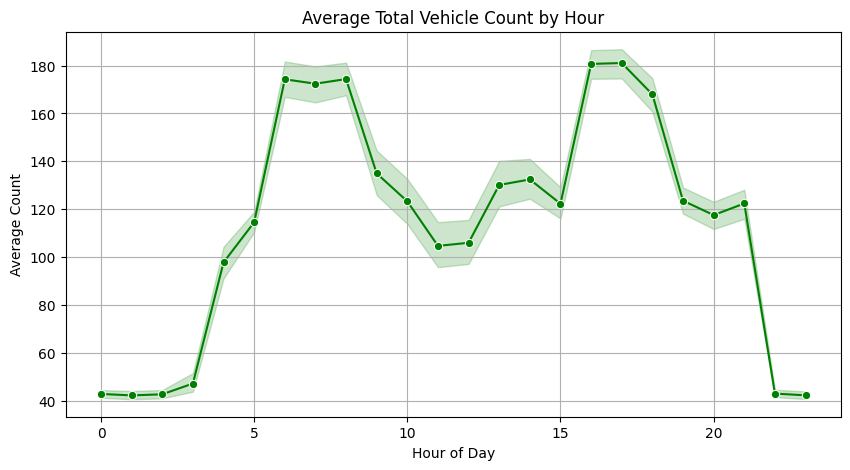

In [ ]:
# 3. Average Total Vehicle Count by Hour
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='Hour', y='Total', estimator='mean', marker='o', color='green')
plt.title('Average Total Vehicle Count by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Count')
plt.grid(True)
plt.show()

/tmp/ipython-input-2050564656.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Day of the week', y='Total', palette='pastel')


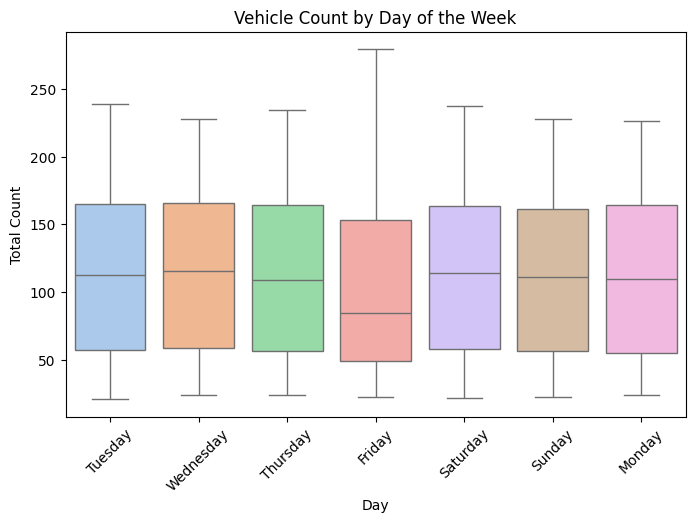

In [ ]:
# 4. Total Vehicle Count per Day of the Week
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Day of the week', y='Total', palette='pastel')
plt.title('Vehicle Count by Day of the Week')
plt.xlabel('Day')
plt.ylabel('Total Count')
plt.xticks(rotation=45)
plt.show()


/tmp/ipython-input-2496993399.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Traffic Situation', data=df, palette='coolwarm')


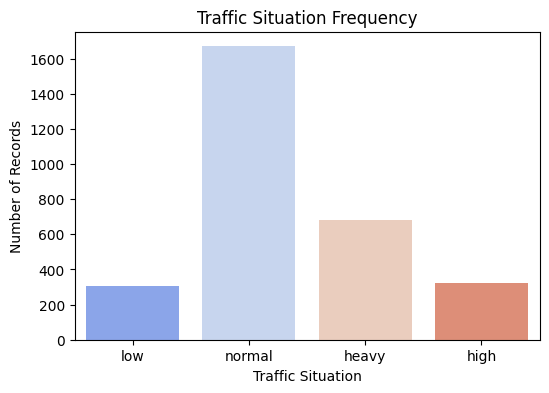

In [ ]:
# 5. Count Plot for Traffic Situation
plt.figure(figsize=(6, 4))
sns.countplot(x='Traffic Situation', data=df, palette='coolwarm')
plt.title('Traffic Situation Frequency')
plt.ylabel('Number of Records')
plt.xlabel('Traffic Situation')
plt.show()



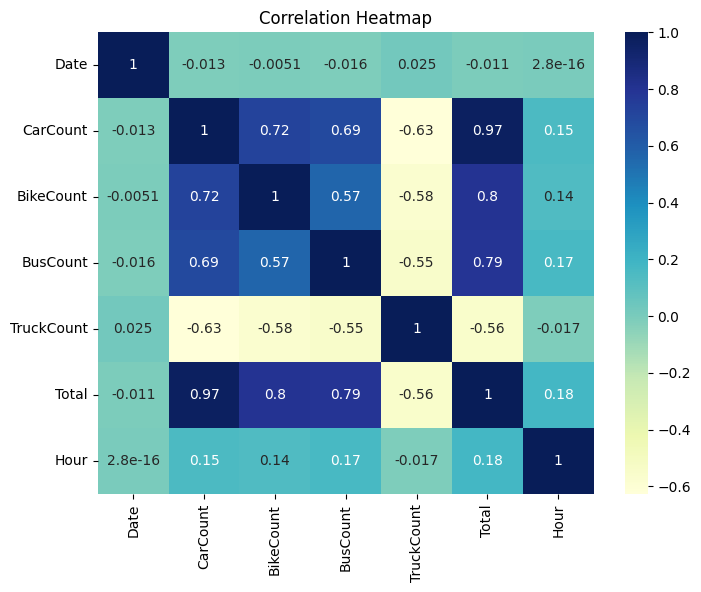

In [ ]:
# 6. Correlation Heatmap (for numeric only)
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='YlGnBu')
plt.title("Correlation Heatmap")
plt.show()

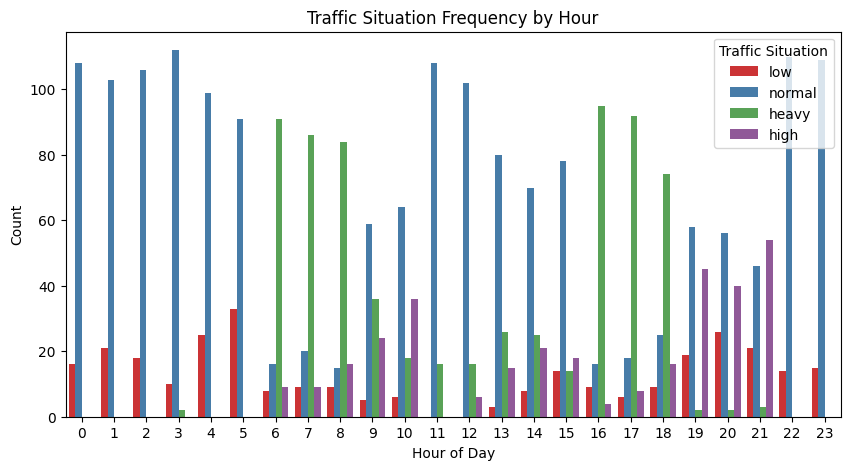

In [ ]:
# 7. Traffic Situation Frequency by Hour
plt.figure(figsize=(10, 5))
sns.countplot(x='Hour', hue='Traffic Situation', data=df, palette='Set1')
plt.title('Traffic Situation Frequency by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Count')
plt.legend(title='Traffic Situation')
plt.show()


# Data Preprocessing

In [ ]:
# Drop individual vehicle counts to avoid redundancy
df.drop(columns=['CarCount', 'BikeCount', 'BusCount', 'TruckCount'], inplace=True)

# Convert Time to hour
df['Time'] = pd.to_datetime(df['Time'], format='%I:%M:%S %p')
df['Hour'] = df['Time'].dt.hour
df.drop(columns=['Time'], inplace=True)

In [ ]:
# Preview the dataset
print("Initial Data Snapshot:")
print(df.head(15))

Initial Data Snapshot:
    Date Day of the week  Total Traffic Situation  Hour
0     10         Tuesday     39               low     0
1     10         Tuesday     55               low     0
2     10         Tuesday     55               low     0
3     10         Tuesday     58               low     0
4     10         Tuesday     94            normal     1
5     10         Tuesday     53               low     1
6     10         Tuesday     42               low     1
7     10         Tuesday     55               low     1
8     10         Tuesday     67               low     2
9     10         Tuesday     45               low     2
10    10         Tuesday     47               low     2
11    10         Tuesday     49               low     2
12    10         Tuesday     53               low     3
13    10         Tuesday     42               low     3
14    10         Tuesday    194             heavy     3



Numerical Columns: ['Date', 'Total', 'Hour']


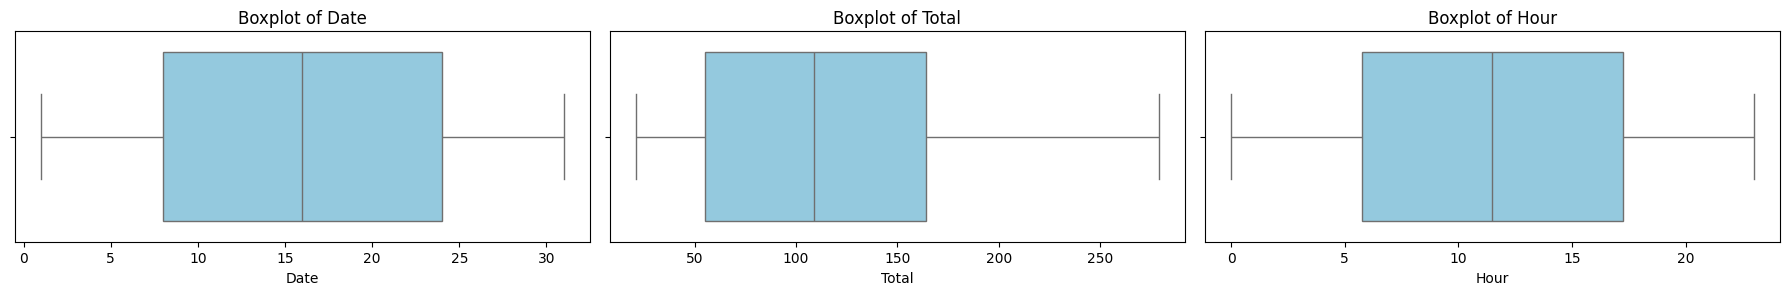

In [ ]:

# Select numerical columns (now includes Count_per_Hour)
numerical_columns = df.select_dtypes(include=[np.number]).columns
print("\nNumerical Columns:", list(numerical_columns))

# Boxplots to check for outliers
plt.figure(figsize=(18, 8))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()


In [ ]:
# Drop outliers using IQR method on selected numerical columns
def drop_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Apply to selected columns
df_clean = df.copy()
for col in ['Total']:  # include other columns if needed
    df_clean = drop_outliers_iqr(df_clean, col)

print("\nShape before dropping outliers:", df.shape)
print("Shape after dropping outliers:", df_clean.shape)



Shape before dropping outliers: (2976, 5)
Shape after dropping outliers: (2976, 5)


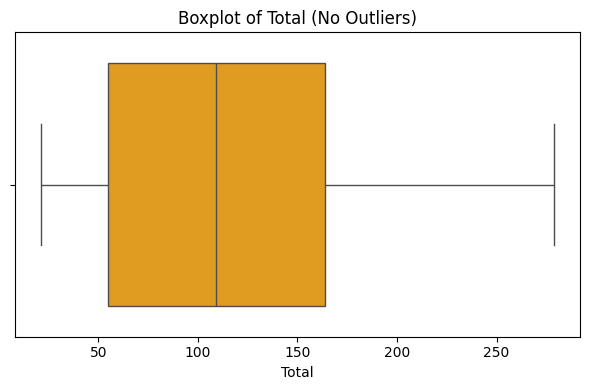

In [ ]:
# Visualize cleaned column ---
plt.figure(figsize=(6, 4))
sns.boxplot(x=df_clean['Total'], color='orange')
plt.title('Boxplot of Total (No Outliers)')
plt.tight_layout()
plt.show()

df = df_clean.copy()

In [ ]:
# Show categorical (non-numeric) columns ---
cat_cols = df.select_dtypes(exclude=[np.number]).columns
print("\nCategorical Columns:", list(cat_cols))
print(df[cat_cols].head())


Categorical Columns: ['Day of the week', 'Traffic Situation']
  Day of the week Traffic Situation
0         Tuesday               low
1         Tuesday               low
2         Tuesday               low
3         Tuesday               low
4         Tuesday            normal


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode 'Day of the week'
le_day = LabelEncoder()
df['Day of the week'] = le_day.fit_transform(df['Day of the week'])
print("Encoded 'Day of the week'.")

# Encode 'Traffic Situation'
le_traffic = LabelEncoder()
df['Traffic Situation'] = le_traffic.fit_transform(df['Traffic Situation'])
print("Encoded 'Traffic Situation'.")

# Create additional feature
df['Traffic_Situation_per_Hour'] = df['Traffic Situation'] / (df['Hour'] + 1)

print("Created 'Traffic_Situation_per_Hour' feature.")




Encoded 'Day of the week'.
Encoded 'Traffic Situation'.
Created 'Traffic_Situation_per_Hour' feature.


In [ ]:
# Check for missing data ---
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Date                          0
Day of the week               0
Total                         0
Traffic Situation             0
Hour                          0
Traffic_Situation_per_Hour    0
dtype: int64


In [ ]:
# Numerical columns
numerical_columns = df.select_dtypes(include=['number']).columns
print("Numerical Columns:")
print(numerical_columns)

# Categorical columns
categorical_columns = df.select_dtypes(exclude=['number']).columns
print("\nCategorical Columns:")
print(categorical_columns)


Numerical Columns:
Index(['Date', 'Day of the week', 'Total', 'Traffic Situation', 'Hour',
       'Traffic_Situation_per_Hour'],
      dtype='object')

Categorical Columns:
Index([], dtype='object')


In [ ]:
# Define features and target
X = df.drop(columns=['Total'])
y = df['Total']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the model
model = RandomForestRegressor(random_state=42)
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)

# Evaluate
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# results
print("R² Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R² Score: 0.8656411681366412
MAE: 15.758145199599058
RMSE: 21.28148968289658


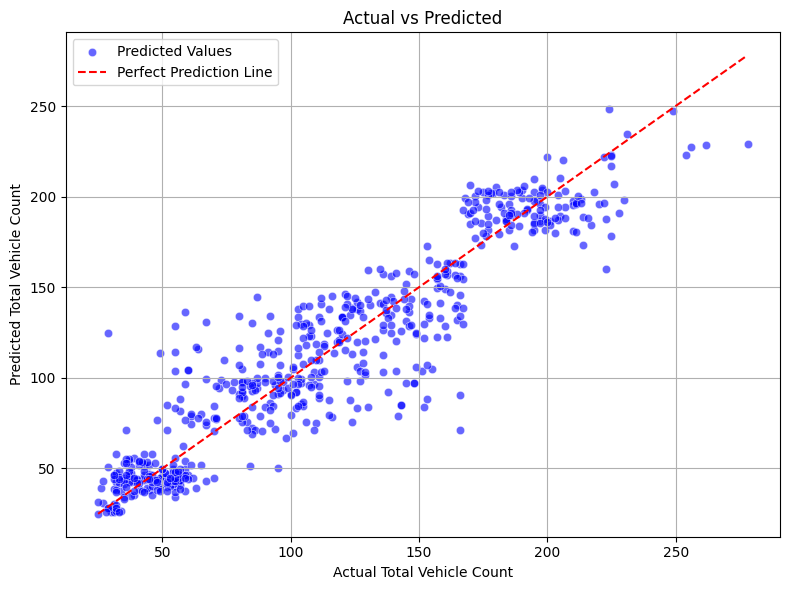

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

# Plot predicted points
sns.scatterplot(x=y_test, y=y_pred, color='blue', alpha=0.6, label='Predicted Values')

# Plot perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    label='Perfect Prediction Line'
)

# Labels and title
plt.xlabel('Actual Total Vehicle Count')
plt.ylabel('Predicted Total Vehicle Count')
plt.title('Actual vs Predicted')
plt.grid(True)

# Add legend (key)
plt.legend()

plt.tight_layout()
plt.show()